In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Python Project/credit_card_fraud_10k.csv")
print(df.head())


   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [6]:
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:", df.shape)



Dataset Shape After Removing Duplicates: (10000, 10)


In [7]:
print("\nData Types:")
print(df.dtypes)


Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [10]:
print("""DESCRIPTIVE STATISTICS""")

print("\nStatistical Summary:")
print(df.describe())

# Average transaction amount
avg_amount = df["amount"].mean()
print("\nAverage Transaction Amount:", avg_amount)

# Fraud vs Normal transaction count
fraud_count = df["is_fraud"].value_counts()

print("\nFraud vs Normal Transactions:")
print(fraud_count)

"""FRAUD BEHAVIOR ANALYSIS"""

normal_transactions = df[df["is_fraud"] == 0]
fraud_transactions = df[df["is_fraud"] == 1]

print("\nNormal Transactions:")
print(normal_transactions.describe())

print("\nFraud Transactions:")
print(fraud_transactions.describe())

"""GROUP BASED ANALYSIS"""

# Average amount by class
group_analysis = df.groupby("is_fraud")["amount"].mean()

print("\nAverage Transaction Amount by Class:")
print(group_analysis)

"""RELATIONSHIP ANALYSIS"""

# Exclude non-numeric columns before calculating correlation
correlation = df.drop(columns=['merchant_category']).corr()

DESCRIPTIVE STATISTICS

Statistical Summary:
       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053       

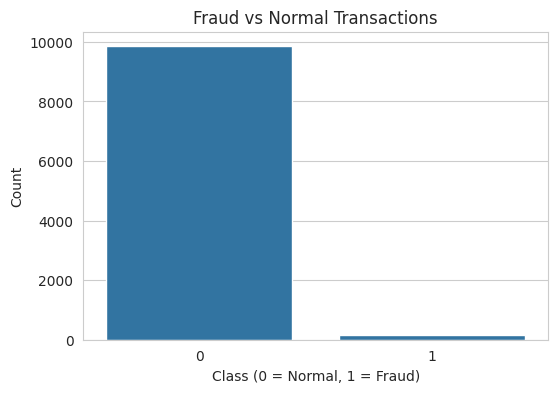

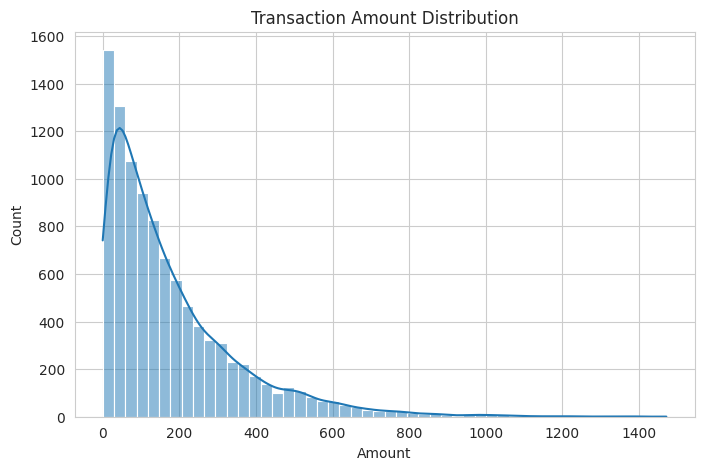

In [12]:
"""DATA VISUALIZATION"""

sns.set_style("whitegrid")

"""Fraud Distribution"""

plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

"""Transaction Amount Distribution"""

plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

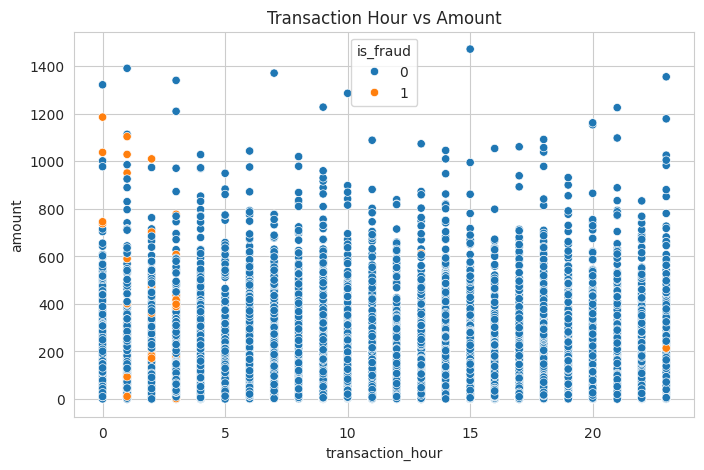

In [14]:
"""Scatter Plot"""

plt.figure(figsize=(8,5))
sns.scatterplot(x='transaction_hour', y='amount', hue='is_fraud', data=df)
plt.title("Transaction Hour vs Amount")
plt.show()

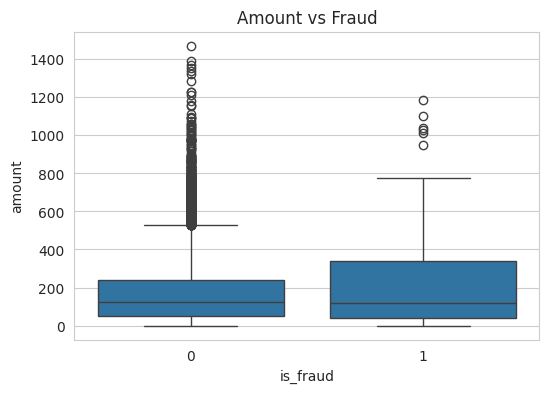

In [16]:
"""Box Plot"""

plt.figure(figsize=(6,4))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

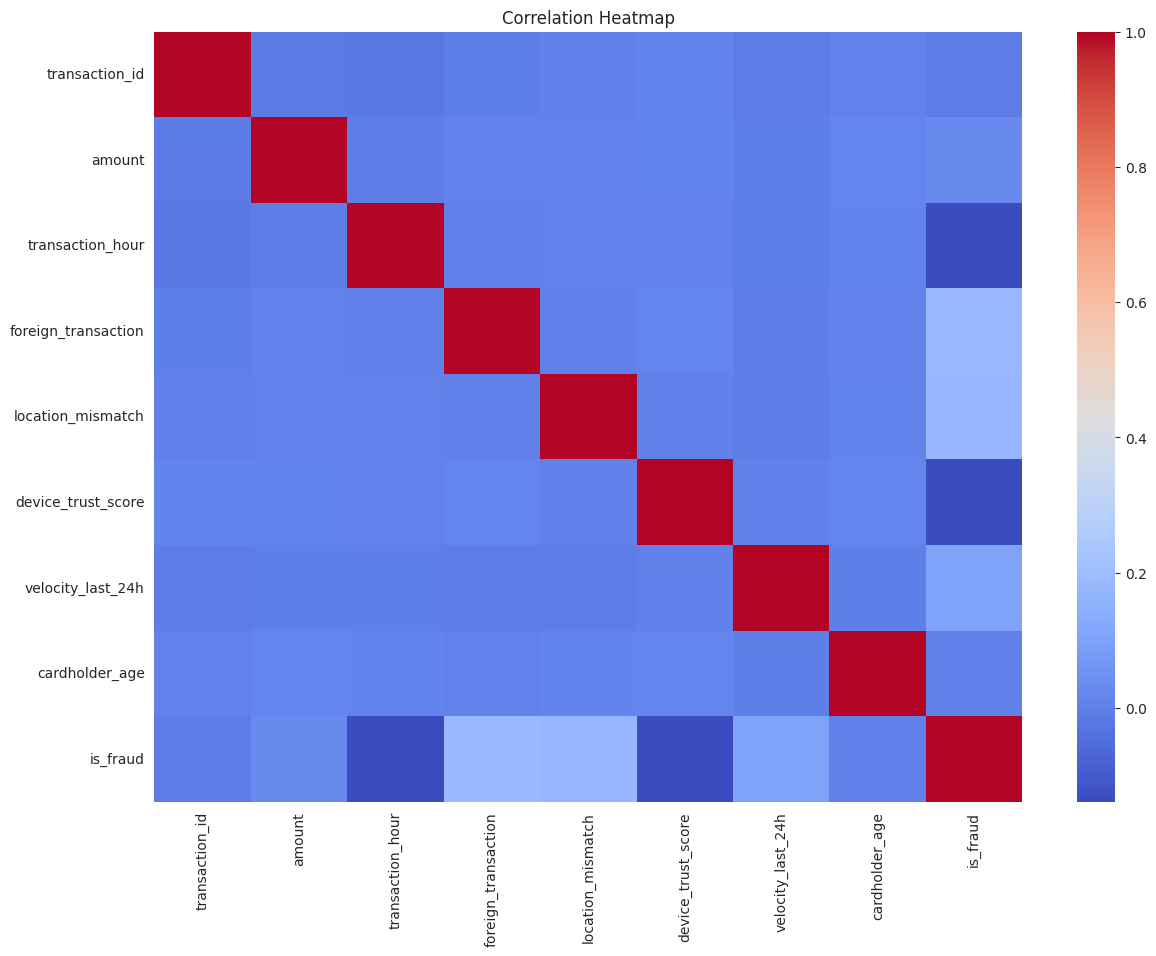

In [17]:

"""Correlation Heatmap"""

plt.figure(figsize=(14,10))
sns.heatmap(correlation, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# Risk Analysis

def risk_level(amount):
    if amount < 100:
        return "Low Risk"
    elif amount < 1000:
        return "Medium Risk"
    else:
        return "High Risk"

df["Risk_Level"] = df["amount"].apply(risk_level)

print("\nRisk Level Distribution:")
print(df["Risk_Level"].value_counts())


Risk Level Distribution:
Risk_Level
Medium Risk    5627
Low Risk       4338
High Risk        35
Name: count, dtype: int64


In [24]:
# LINEAR REGRESSION MODEL

# Independent Variables
X = df[['transaction_hour']]

# Dependent Variable
y = df['amount']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


Model Evaluation
R2 Score: -0.0002134551260764006
Mean Squared Error: 30892.6102545943


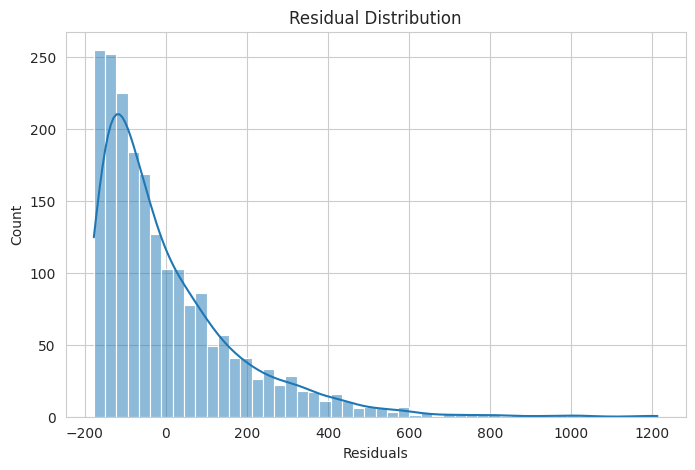

In [25]:
"""MODEL EVALUATION"""

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nModel Evaluation")
print("R2 Score:", r2)
print("Mean Squared Error:", mse)

"""RESIDUAL ANALYSIS"""

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

In [27]:

"""INTERACTIVE DASHBOARD"""

# Fraud Distribution Chart
fig1 = px.histogram(
    df,
    x="is_fraud",
    title="Fraud vs Normal Transactions",
    labels={"is_fraud": "Transaction Type"}
)

fig1.show()

# Transaction Amount Trend
fig2 = px.scatter(
    df,
    x="transaction_hour",
    y="amount",
    color="is_fraud",
    title="Transaction Amount Over Time"
)
fig2.show()

In [28]:
# Risk Level Chart
fig3 = px.pie(
    df,
    names="Risk_Level",
    title="Risk Level Distribution"
)

fig3.show()

# Correlation Heatmap
fig4 = go.Figure(
    data=go.Heatmap(
        z=correlation.values,
        x=correlation.columns,
        y=correlation.columns,
        colorscale='Viridis'
    )
)


In [29]:

""" INSIGHTS & CONCLUSION"""

print("\nPROJECT INSIGHTS")
print("---------------------------")
print("1. Fraud transactions are very low compared to normal transactions.")
print("2. Transaction amount plays an important role in fraud detection.")
print("3. Some features show strong correlations with fraudulent activity.")
print("4. High-risk transactions can be identified using amount patterns.")
print("5. Dashboard visualizations help understand fraud behavior easily.")

print("\nThis Project Was Completed Successfully.")


PROJECT INSIGHTS
---------------------------
1. Fraud transactions are very low compared to normal transactions.
2. Transaction amount plays an important role in fraud detection.
3. Some features show strong correlations with fraudulent activity.
4. High-risk transactions can be identified using amount patterns.
5. Dashboard visualizations help understand fraud behavior easily.

This Project Was Completed Successfully.
